In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load the dataset from scikit-learn
data = fetch_california_housing(as_frame=True)

# Combine the features and the target house values into a table
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

# Display the first 5 rows of the data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
# Separate our inputs (X) from our target house value (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data successfully split!
Training samples: 16512, Testing samples: 4128


In [8]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [10]:
# Predict house prices using the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
# Calculate MSE first, then use numpy to get the square root (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the final scores
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score (R-squared): {r2:.3f}")

Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R² Score (R-squared): 0.576


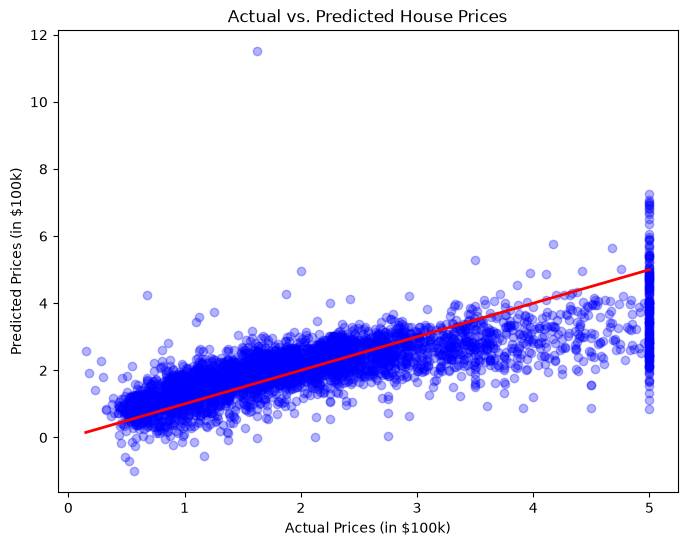

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Plot actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

# Draw a diagonal line representing a perfect predictor
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.xlabel("Actual Prices (in $100k)")
plt.ylabel("Predicted Prices (in $100k)")
plt.title("Actual vs. Predicted House Prices")
plt.show()